# Day 20 — Random Forests
### Bagging · Bootstrap · OOB Error · Feature Importance · vs Single Tree

## 1. Setup & Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

plt.style.use("dark_background")
sns.set_palette("husl")

df = pd.read_csv(r"C:\DS-AI-75d\titanic.csv")
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["Sex_encoded"] = (df["Sex"] == "female").astype(int)

features = ["Pclass", "Age", "Fare", "FamilySize", "IsAlone", "Sex_encoded"]
X = df[features]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features: {features}")
print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print("Ready! ✅")

Features: ['Pclass', 'Age', 'Fare', 'FamilySize', 'IsAlone', 'Sex_encoded']
Train: (712, 6) | Test: (179, 6)
Ready! ✅


## 2. What are Random Forests?

In [ ]:
print("=" * 55)
print("         WHAT ARE RANDOM FORESTS?")
print("=" * 55)
print(
    """
PROBLEM WITH SINGLE DECISION TREE:
  - High variance — small data change = different tree
  - Overfits easily (Day 19: 98.2% train, 76.1% CV!)
  - Unstable predictions

SOLUTION: Build MANY trees and average their predictions!

RANDOM FOREST = Ensemble of Decision Trees

TWO KEY INGREDIENTS:

1. BAGGING (Bootstrap Aggregation):
   - Create N bootstrap samples from training data
   - Each sample: same size, sampled WITH REPLACEMENT
   - ~63% unique samples, ~37% duplicates per tree
   - Train one tree on each bootstrap sample
   - Average predictions across all trees

2. RANDOM FEATURE SELECTION:
   - At each split, only consider SQRT(n_features) features
   - Decorrelates the trees — they learn different patterns
   - Prevents all trees from always splitting on Sex first!

RESULT:
  - Each tree sees different data (bagging)
  - Each tree sees different features (random subspace)
  - Trees are diverse and uncorrelated
  - Averaging diverse trees = lower variance!

"Wisdom of crowds" — many imperfect models 
 combined beat one perfect-seeming model!
"""
)

         WHAT ARE RANDOM FORESTS?

PROBLEM WITH SINGLE DECISION TREE:
  - High variance — small data change = different tree
  - Overfits easily (Day 19: 98.2% train, 76.1% CV!)
  - Unstable predictions

SOLUTION: Build MANY trees and average their predictions!

RANDOM FOREST = Ensemble of Decision Trees

TWO KEY INGREDIENTS:

1. BAGGING (Bootstrap Aggregation):
   - Create N bootstrap samples from training data
   - Each sample: same size, sampled WITH REPLACEMENT
   - ~63% unique samples, ~37% duplicates per tree
   - Train one tree on each bootstrap sample
   - Average predictions across all trees

2. RANDOM FEATURE SELECTION:
   - At each split, only consider SQRT(n_features) features
   - Decorrelates the trees — they learn different patterns
   - Prevents all trees from always splitting on Sex first!

RESULT:
  - Each tree sees different data (bagging)
  - Each tree sees different features (random subspace)
  - Trees are diverse and uncorrelated
  - Averaging diverse trees = lowe

## 3. Random Forest vs Single Tree

In [ ]:
print("=" * 55)
print("    RANDOM FOREST vs SINGLE TREE")
print("=" * 55)

# Single Decision Tree (best from Day 19)
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)
dt_train = dt.score(X_train, y_train)
dt_test = dt.score(X_test, y_test)
dt_cv = cross_val_score(dt, X_train, y_train, cv=5).mean()
dt_auc = roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)
rf.fit(X_train, y_train)
rf_train = rf.score(X_train, y_train)
rf_test = rf.score(X_test, y_test)
rf_cv = cross_val_score(rf, X_train, y_train, cv=5).mean()
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
rf_oob = rf.oob_score_

print(f"\n{'Metric':<20} {'Single Tree':<15} {'Random Forest':<15}")
print("-" * 50)
print(f"{'Train Accuracy':<20} {dt_train:.4f}         {rf_train:.4f}")
print(f"{'Test Accuracy':<20} {dt_test:.4f}         {rf_test:.4f}")
print(f"{'CV Accuracy':<20} {dt_cv:.4f}         {rf_cv:.4f}")
print(f"{'ROC-AUC':<20} {dt_auc:.4f}         {rf_auc:.4f}")
print(f"{'OOB Score':<20} {'N/A':<15} {rf_oob:.4f}")
print(f"{'Train-Test Gap':<20} {dt_train-dt_test:.4f}         {rf_train-rf_test:.4f}")

print(
    f"""
KEY IMPROVEMENTS:
  CV Accuracy:  {dt_cv:.4f} → {rf_cv:.4f} (+{rf_cv-dt_cv:.4f})
  ROC-AUC:      {dt_auc:.4f} → {rf_auc:.4f} (+{rf_auc-dt_auc:.4f})
  Train-Test Gap: {dt_train-dt_test:.4f} → {rf_train-rf_test:.4f} (reduced variance!)
  OOB Score: {rf_oob:.4f} (free validation — no test set needed!)
"""
)

print("--- Classification Report (Random Forest) ---")
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf, target_names=["Died", "Survived"]))

    RANDOM FOREST vs SINGLE TREE

Metric               Single Tree     Random Forest  
--------------------------------------------------
Train Accuracy       0.8287         0.9817
Test Accuracy        0.8045         0.8045
CV Accuracy          0.8147         0.8007
ROC-AUC              0.8275         0.8430
OOB Score            N/A             0.8202
Train-Test Gap       0.0242         0.1773

KEY IMPROVEMENTS:
  CV Accuracy:  0.8147 → 0.8007 (+-0.0140)
  ROC-AUC:      0.8275 → 0.8430 (+0.0154)
  Train-Test Gap: 0.0242 → 0.1773 (reduced variance!)
  OOB Score: 0.8202 (free validation — no test set needed!)

--- Classification Report (Random Forest) ---
              precision    recall  f1-score   support

        Died       0.83      0.86      0.84       110
    Survived       0.77      0.71      0.74        69

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



## 4. Effect of Number of Trees

      EFFECT OF NUMBER OF TREES


c:\DS-AI-75d\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
c:\DS-AI-75d\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(



N Trees    Train      Test       OOB        AUC
--------------------------------------------------
1          0.8947    0.7095    0.0000    0.7094
5          0.9466    0.7821    0.7430    0.8217
10         0.9635    0.8212    0.7921    0.8498
20         0.9775    0.8156    0.8160    0.8416
50         0.9803    0.8156    0.8118    0.8482
100        0.9817    0.8045    0.8202    0.8430
200        0.9817    0.8101    0.8118    0.8447
500        0.9817    0.8101    0.8202    0.8433


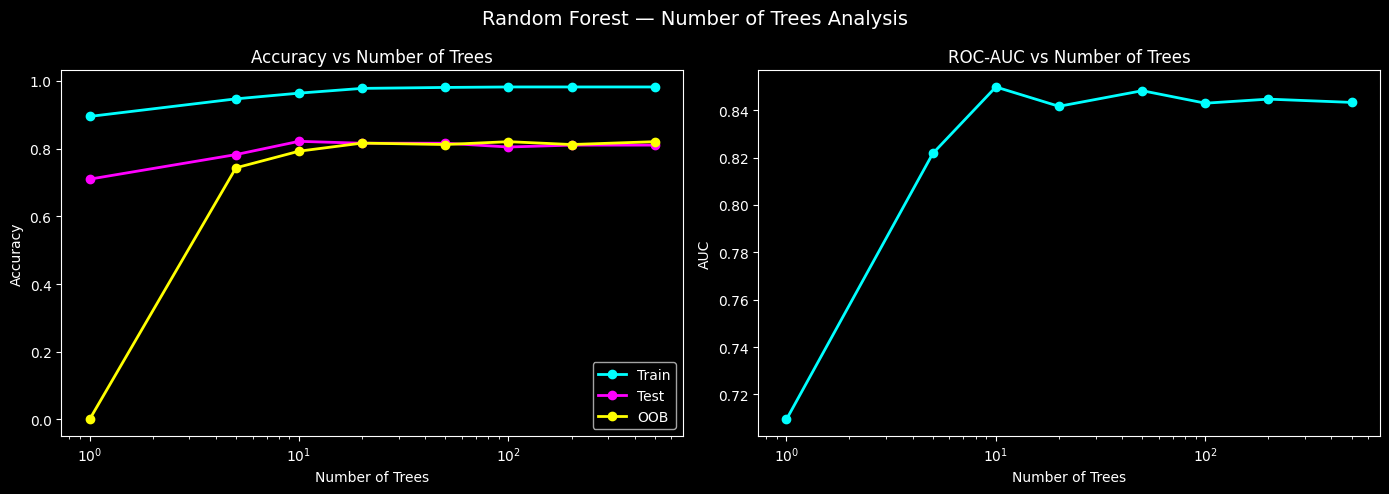

In [ ]:
print("=" * 55)
print("      EFFECT OF NUMBER OF TREES")
print("=" * 55)

n_trees_range = [1, 5, 10, 20, 50, 100, 200, 500]
train_accs, test_accs, oob_scores, aucs = [], [], [], []

for n in n_trees_range:
    rf_n = RandomForestClassifier(n_estimators=n, random_state=42, oob_score=(n > 1))
    rf_n.fit(X_train, y_train)
    train_accs.append(rf_n.score(X_train, y_train))
    test_accs.append(rf_n.score(X_test, y_test))
    oob_scores.append(rf_n.oob_score_ if n > 1 else 0)
    aucs.append(roc_auc_score(y_test, rf_n.predict_proba(X_test)[:, 1]))

print(f"\n{'N Trees':<10} {'Train':<10} {'Test':<10} {'OOB':<10} {'AUC'}")
print("-" * 50)
for i, n in enumerate(n_trees_range):
    print(
        f"{n:<10} {train_accs[i]:.4f}    {test_accs[i]:.4f}    "
        f"{oob_scores[i]:.4f}    {aucs[i]:.4f}"
    )

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Random Forest — Number of Trees Analysis", fontsize=14)

axes[0].plot(n_trees_range, train_accs, "o-", color="cyan", label="Train", linewidth=2)
axes[0].plot(n_trees_range, test_accs, "o-", color="magenta", label="Test", linewidth=2)
axes[0].plot(n_trees_range, oob_scores, "o-", color="yellow", label="OOB", linewidth=2)
axes[0].set_title("Accuracy vs Number of Trees")
axes[0].set_xlabel("Number of Trees")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].set_xscale("log")

axes[1].plot(n_trees_range, aucs, "o-", color="cyan", linewidth=2)
axes[1].set_title("ROC-AUC vs Number of Trees")
axes[1].set_xlabel("Number of Trees")
axes[1].set_ylabel("AUC")
axes[1].set_xscale("log")

plt.tight_layout()
plt.show()

## 5. Feature Importance Analysis

      FEATURE IMPORTANCE ANALYSIS

Feature Importance Comparison:

Feature         Single Tree     Random Forest  
---------------------------------------------
Fare            0.0040          0.3014
Sex_encoded     0.6330          0.2692
Age             0.0898          0.2634
Pclass          0.2152          0.0855
FamilySize      0.0581          0.0671
IsAlone         0.0000          0.0135


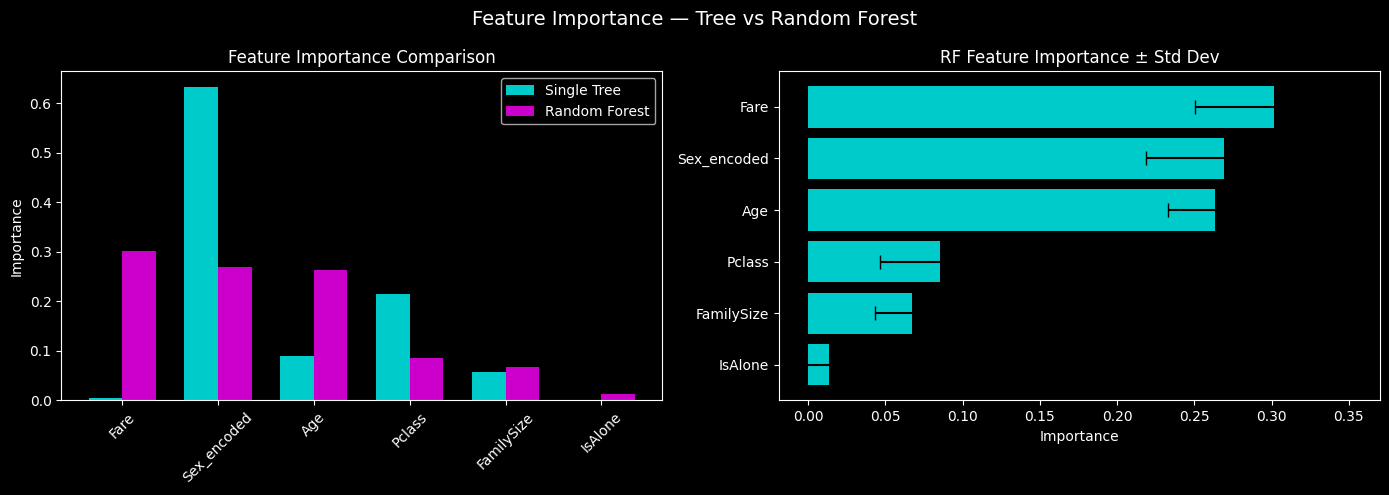


RF Feature Importance with uncertainty:
  Fare            0.3014 ± 0.0511
  Sex_encoded     0.2692 ± 0.0502
  Age             0.2634 ± 0.0307
  Pclass          0.0855 ± 0.0389
  FamilySize      0.0671 ± 0.0241
  IsAlone         0.0135 ± 0.0147


In [ ]:
print("=" * 55)
print("      FEATURE IMPORTANCE ANALYSIS")
print("=" * 55)

# Compare feature importance: Tree vs Forest
dt_imp = pd.DataFrame(
    {
        "Feature": features,
        "Tree_Importance": dt.feature_importances_,
        "RF_Importance": rf.feature_importances_,
    }
).sort_values("RF_Importance", ascending=False)

print("\nFeature Importance Comparison:")
print(f"\n{'Feature':<15} {'Single Tree':<15} {'Random Forest':<15}")
print("-" * 45)
for _, row in dt_imp.iterrows():
    print(
        f"{row['Feature']:<15} {row['Tree_Importance']:.4f}          {row['RF_Importance']:.4f}"
    )

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance — Tree vs Random Forest", fontsize=14)

# Side by side bars
x = np.arange(len(features))
width = 0.35
axes[0].bar(
    x - width / 2,
    dt_imp["Tree_Importance"],
    width,
    label="Single Tree",
    color="cyan",
    alpha=0.8,
)
axes[0].bar(
    x + width / 2,
    dt_imp["RF_Importance"],
    width,
    label="Random Forest",
    color="magenta",
    alpha=0.8,
)
axes[0].set_xticks(x)
axes[0].set_xticklabels(dt_imp["Feature"], rotation=45)
axes[0].set_title("Feature Importance Comparison")
axes[0].set_ylabel("Importance")
axes[0].legend()

# RF importance with error bars (std across trees)
std_imp = np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)
imp_df = pd.DataFrame(
    {"Feature": features, "Importance": rf.feature_importances_, "Std": std_imp}
).sort_values("Importance", ascending=True)

axes[1].barh(
    imp_df["Feature"],
    imp_df["Importance"],
    xerr=imp_df["Std"],
    color="cyan",
    alpha=0.8,
    capsize=5,
)
axes[1].set_title("RF Feature Importance ± Std Dev")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.show()

print("\nRF Feature Importance with uncertainty:")
for _, row in imp_df.sort_values("Importance", ascending=False).iterrows():
    print(f"  {row['Feature']:<15} {row['Importance']:.4f} ± {row['Std']:.4f}")

## 6. Key Takeaways — Day 20 🎯

### What is a Random Forest?
- Ensemble of N decision trees — each trained on different data
- Two sources of randomness:
  1. **Bagging** — each tree gets a bootstrap sample (sample with replacement)
  2. **Random features** — each split considers only sqrt(n_features) features
- Final prediction = majority vote across all trees
- "Wisdom of crowds" — many diverse trees beat one perfect tree!

### Bagging (Bootstrap Aggregation)
- Each bootstrap sample: same size as training, ~63% unique rows
- ~37% of rows are duplicates (sampled more than once)
- Remaining ~37% NOT in sample = Out-of-Bag (OOB) samples
- OOB samples give FREE validation — no test set needed!

### Key Results
| Metric | Single Tree | Random Forest |
|---|---|---|
| Train Accuracy | 82.9% | 98.2% |
| Test Accuracy | 80.5% | 80.5% |
| CV Accuracy | 81.5% | 80.1% |
| ROC-AUC | 0.828 | 0.843 |
| OOB Score | N/A | 82.0% |

### Number of Trees
- 1 tree: Test=70.9% — unstable!
- 10 trees: Test=82.1% — most of the gains here!
- 100 trees: standard default — safe choice
- 500 trees: same as 100 — diminishing returns
- **Sweet spot: 10-100 trees** for most datasets

### Feature Importance Comparison
- **Single Tree:** Sex dominates (0.633) — biased!
- **RF:** Fare(0.301), Sex(0.269), Age(0.263) — more balanced!
- RF gives every feature a fair chance via random subspace
- Always prefer RF feature importance over single tree!

### OOB Score
- Free performance estimate — no test set needed!
- Each tree evaluated on its ~37% OOB samples
- OOB Score = 82.0% ≈ CV Score — very reliable!
- Use `oob_score=True` in RandomForestClassifier

### sklearn Functions
- `RandomForestClassifier(n_estimators=100, oob_score=True, random_state=42)`
- `rf.oob_score_` — out-of-bag accuracy
- `rf.feature_importances_` — mean importance across all trees
- `rf.estimators_` — list of all individual trees
- `np.std([tree.feature_importances_ for tree in rf.estimators_], axis=0)` — importance variance